In [47]:
!unzip data.zip

Streaming output truncated to the last 5000 lines.
  inflating: data/REAL/4505.jpg      
  inflating: data/REAL/4506 (10).jpg  
  inflating: data/REAL/4506 (2).jpg  
  inflating: data/REAL/4506 (3).jpg  
  inflating: data/REAL/4506 (4).jpg  
  inflating: data/REAL/4506 (5).jpg  
  inflating: data/REAL/4506 (6).jpg  
  inflating: data/REAL/4506 (7).jpg  
  inflating: data/REAL/4506 (8).jpg  
  inflating: data/REAL/4506 (9).jpg  
  inflating: data/REAL/4506.jpg      
  inflating: data/REAL/4507 (10).jpg  
  inflating: data/REAL/4507 (2).jpg  
  inflating: data/REAL/4507 (3).jpg  
  inflating: data/REAL/4507 (4).jpg  
  inflating: data/REAL/4507 (5).jpg  
  inflating: data/REAL/4507 (6).jpg  
  inflating: data/REAL/4507 (7).jpg  
  inflating: data/REAL/4507 (8).jpg  
  inflating: data/REAL/4507 (9).jpg  
  inflating: data/REAL/4507.jpg      
  inflating: data/REAL/4508 (10).jpg  
  inflating: data/REAL/4508 (2).jpg  
  inflating: data/REAL/4508 (3).jpg  
  inflating: data/REAL/4508 (4).jp

In [48]:
import tensorflow as tf
import os

In [49]:
pip install opencv-python

In [50]:
pip install matplotlib

In [51]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [52]:
import cv2
import imghdr
from matplotlib import pyplot as plt
import numpy as np

In [53]:
img = cv2.imread(os.path.join('data', 'FAKE', '1000 (6).jpg'))

In [54]:
img.shape

(32, 32, 3)

In [55]:
data = tf.keras.utils.image_dataset_from_directory('data', image_size=(32, 32))

Found 55214 files belonging to 2 classes.


In [56]:
data_it = data.as_numpy_iterator()

In [57]:
batch = data_it.next()

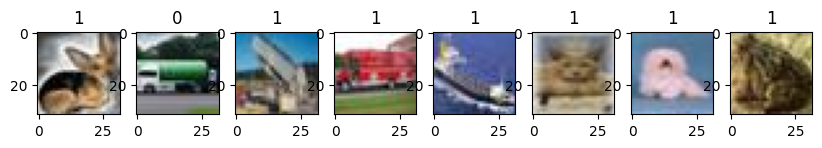

In [58]:
fig, ax = plt.subplots(ncols=8, figsize=(10, 10))
for idx, img in enumerate(batch[0][:8]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [59]:
print(batch[0].min())
print(batch[0].max())

0.0
255.0


In [60]:
data = data.map(lambda x, y : (x/255, y))

In [61]:
scaled_it = data.as_numpy_iterator()

In [62]:
batch = scaled_it.next()

In [63]:
print(batch[0].min())
print(batch[0].max())

0.0
1.0


In [64]:
len(data)

1726

In [65]:
train_size = int(len(data)*0.7)
cv_size = int(len(data)*0.2)
test_size = int(len(data)*0.1)+1
train_size+cv_size+test_size

1726

In [66]:
train = data.take(train_size)
cv = data.skip(train_size).take(cv_size)
test = data.skip(train_size+cv_size).take(test_size)
len(train)+len(cv)+len(test)

1726

In [67]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

In [68]:
model = Sequential()

In [69]:
model.add(Conv2D(16, (4, 4), 1, activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPooling2D())

model.add(Conv2D(32, (4, 4), 1, activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16, (4, 4), 1, activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [70]:
model.compile('adam', loss = tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [71]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 16)     │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 2, 2, 16)       │         8,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,793 (69.50 KB)

 Trainable params: 17,793 (69.50 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
logdir = 'logs'
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)
hist = model.fit(train, epochs=30, validation_data=cv, callbacks=[tensorboard_callback])

Epoch 1/30
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.9095 - loss: 0.2795 - val_accuracy: 0.9174 - val_loss: 0.2375
Epoch 2/30
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9203 - loss: 0.2199 - val_accuracy: 0.9261 - val_loss: 0.2011
Epoch 3/30
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9297 - loss: 0.1921 - val_accuracy: 0.9345 - val_loss: 0.1747
Epoch 4/30
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9343 - loss: 0.1754 - val_accuracy: 0.9356 - val_loss: 0.1702
Epoch 5/30
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9390 - loss: 0.1626 - val_accuracy: 0.9370 - val_loss: 0.1668
Epoch 6/30
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9430 - loss: 0.1522 - val_accuracy: 0.9389 - val_loss: 0.1738
Epoch 7/30
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9459 - loss: 0.1446 - val_accuracy: 0.9381 - val_loss: 0.1712
Epoch 8/30
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9499 -

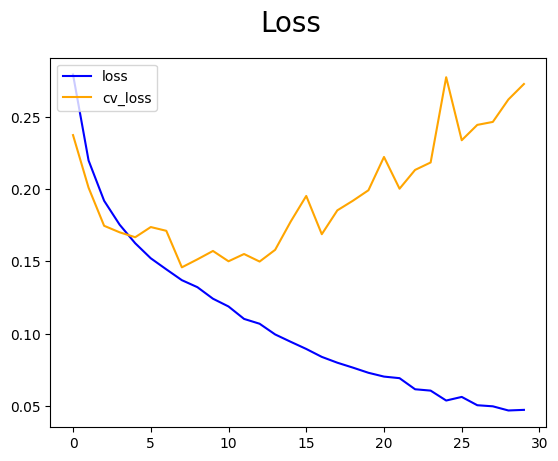

In [73]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='blue', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='cv_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

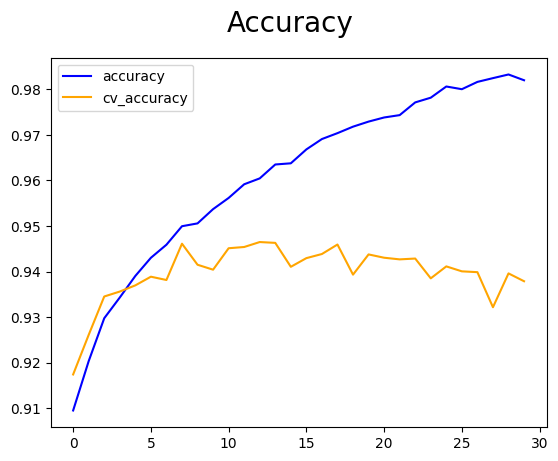

In [74]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='blue', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='cv_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [75]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy
pre = Precision()
rec = Recall()
acc = BinaryAccuracy()
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y, yhat)
    rec.update_state(y, yhat)
    acc.update_state(y, yhat)
    print(f'Precision: {pre.result().numpy()}, Recall: {rec.result().numpy()}, Accuracy: {acc.result().numpy()}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step
Precision: 1.0, Recall: 0.9666666388511658, Accuracy: 0.96875
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Precision: 1.0, Recall: 0.9833333492279053, Accuracy: 0.984375
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Precision: 1.0, Recall: 0.9670329689979553, Accuracy: 0.96875
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Precision: 0.9830508232116699, Recall: 0.9666666388511658, Accuracy: 0.953125
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Precision: 0.9729729890823364, Recall: 0.9729729890823364, Accuracy: 0.949999988079071
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Precision: 0.977142870426178, Recall: 0.9553072452545166, Accuracy: 0.9375
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Precision: 0.9753694534301758, Recall: 0.95652174949646, Accuracy: 0.9375
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Precision: 0.978723406791687, Recall: 0.9623430967330933, Accuracy: 0.9453125
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Precision: 0.9734848737716675, Recall: 0.9661654233932495, Accuracy: 0.9444444

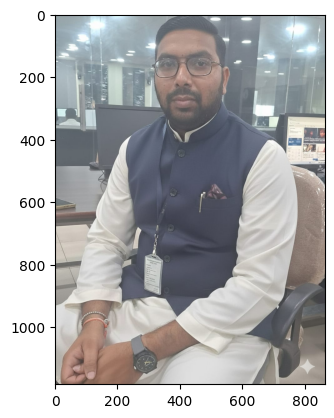

In [83]:
from tensorflow.keras.models import load_model
model.save(os.path.join('model','ai_imageclassifier.h5'))
model = load_model(os.path.join('model','ai_imageclassifier.h5'))
img = cv2.imread('/content/data/FAKE/mani.jpeg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

In [85]:
resize = tf.image.resize(img, (32, 32))

In [86]:
y_pred = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step


In [87]:
y_pred

array([[0.00847446]], dtype=float32)

In [88]:
if y_pred > 0.5:
    print(f'Predicted class: REAL')
else:
    print(f'Predicted class: AI')

Predicted class: AI


In [89]:
!pip install fpdf2 gradio


In [ ]:
import gradio as gr
import numpy as np
import cv2
import os
import datetime
import tempfile
import zipfile
import tensorflow as tf
from fpdf import FPDF
import PIL.Image

# MODEL LOADING
# Uncomment the line below and set the correct path to your saved .h5 file.
#from tensorflow.keras.models import load_model
#model = load_model(os.path.join('models','imageclassifier.h5'))

# ── 1. Feature extraction ────────────────────────────────────────────────────
def get_features(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(float)
    return {
        "Noise Score"     : round(cv2.Laplacian(gray, cv2.CV_64F).var(), 1),
        "Edge Density (%)" : round(np.sum(cv2.Canny(gray, 100, 200) > 0) / gray.size * 100, 1),
        "Brightness"      : round(gray.mean(), 1),
        "Contrast"        : round(gray.std(), 1),
        "Colour Variance" : round(np.mean([rgb[:,:,i].std() for i in range(3)]), 1),
    }

# ── 2. Plain-English reasons ─────────────────────────────────────────────────
def get_reasons(feats, is_real):
    n, e, b, c, v = feats.values()
    reasons = []
    if is_real:
        if n >= 80: reasons.append(f"Natural camera noise present (score {n}) - real photos have random sensor texture that AI images lack.")
        if e >= 5:  reasons.append(f"Rich edge structure ({e}%) - complex edges are a hallmark of real-world scenes.")
        if v >= 40: reasons.append(f"High colour variance ({v}) - natural lighting creates uneven colour across channels.")
        if c >= 30: reasons.append(f"Good tonal contrast ({c}) - real scenes show a wide brightness range.")
    else:
        if n < 80:  reasons.append(f"Unnaturally smooth texture (noise {n}) - AI generators produce too-clean images without sensor noise.")
        if e < 5:   reasons.append(f"Low edge density ({e}%) - GAN/diffusion images have softer, simpler edges than real scenes.")
        if v < 40:  reasons.append(f"Uniform colour distribution ({v}) - synthetic images lack lighting variation across colour channels.")
        if b > 160: reasons.append(f"Over-bright image ({b}/255) - AI models tend to produce overly polished, high-brightness outputs.")
    if not reasons:
        reasons.append("The model's deep convolutional filters detected subtle pixel-level patterns consistent with its training decision.")
    return reasons

# ── 3. PDF builder (compact with fpdf2) ──────────────────────────────────────
def make_pdf(img_path, label, conf, feats, reasons):
    is_real = label == "REAL"
    color   = (26, 127, 75) if is_real else (192, 57, 43)
    tstamp  = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    out     = os.path.join(tempfile.gettempdir(), f"report_{label}_{tstamp}.pdf")

    pdf = FPDF()
    pdf.add_page()
    pdf.set_auto_page_break(auto=True, margin=15)

    # ── Header
    pdf.set_font("Helvetica", "B", 18)
    pdf.cell(0, 10, "AI Image Authenticity Report", new_x="LMARGIN", new_y="NEXT", align="C")
    pdf.set_font("Helvetica", "", 9)
    pdf.set_text_color(120, 120, 120)
    pdf.cell(0, 6, datetime.datetime.now().strftime("Generated: %d %B %Y   %H:%M:%S"), new_x="LMARGIN", new_y="NEXT", align="C")
    pdf.set_text_color(0, 0, 0)
    pdf.line(10, pdf.get_y() + 2, 200, pdf.get_y() + 2)
    pdf.set_y(pdf.get_y() + 6)

    # ── Verdict
    pdf.set_text_color(*color)
    pdf.set_font("Helvetica", "B", 20)
    pdf.cell(0, 12, f"VERDICT:  {label}", new_x="LMARGIN", new_y="NEXT", align="C")
    pdf.set_font("Helvetica", "B", 13)
    pdf.cell(0, 8, f"Model Confidence:  {conf:.1f}%", new_x="LMARGIN", new_y="NEXT", align="C")
    pdf.set_text_color(0, 0, 0)
    pdf.line(10, pdf.get_y() + 2, 200, pdf.get_y() + 2)
    pdf.set_y(pdf.get_y() + 6)

    # ── Image
    pdf.set_font("Helvetica", "B", 12)
    pdf.cell(0, 8, "Input Image", new_x="LMARGIN", new_y="NEXT")
    # Temporarily copy image to a pure JPEG without alpha
    try:
        pdf.image(img_path, x=55, w=100)
    except:
        pass # Handle cases where fpdf fails to process image
    pdf.set_y(pdf.get_y() + 4)
    # Reset x-coordinate back to left edge to fix FPDF issue
    pdf.set_x(15)

    # ── Reasons
    pdf.line(10, pdf.get_y(), 200, pdf.get_y())
    pdf.set_y(pdf.get_y() + 4)
    pdf.set_font("Helvetica", "B", 12)
    pdf.cell(0, 8, "Why the Model Made This Decision", new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("Helvetica", "", 10)
    for r in reasons:
        pdf.multi_cell(0, 7, f"  *  {r}", new_x="LMARGIN", new_y="NEXT")
    pdf.set_y(pdf.get_y() + 3)

    # ── Feature table
    pdf.line(10, pdf.get_y(), 200, pdf.get_y())
    pdf.set_y(pdf.get_y() + 4)
    pdf.set_font("Helvetica", "B", 12)
    pdf.cell(0, 8, "Visual Feature Analysis", new_x="LMARGIN", new_y="NEXT")

    meanings = {
        "Noise Score":      "Low = smooth (AI)  |  High = real camera noise",
        "Edge Density (%)": "Low = soft edges (AI)  |  High = sharp edges (Real)",
        "Brightness":       "Very high may indicate AI synthetic gloss",
        "Contrast":         "Low = flat (AI)  |  High = natural tonal range (Real)",
        "Colour Variance":  "Low = uniform colour (AI)  |  High = natural variation (Real)",
    }

    # Table header
    pdf.set_fill_color(26, 26, 46)
    pdf.set_text_color(255, 255, 255)
    pdf.set_font("Helvetica", "B", 9)
    pdf.cell(60, 7, "Metric",         border=1, fill=True)
    pdf.cell(25, 7, "Value",          border=1, fill=True)
    pdf.cell(105, 7, "Meaning",       border=1, fill=True, new_x="LMARGIN", new_y="NEXT")

    pdf.set_text_color(0, 0, 0)
    pdf.set_font("Helvetica", "", 9)
    for i, (k, v) in enumerate(feats.items()):
        pdf.set_fill_color(245, 245, 245) if i % 2 == 0 else pdf.set_fill_color(255, 255, 255)
        pdf.cell(60,  7, k,                border=1, fill=True)
        pdf.cell(25,  7, str(v),           border=1, fill=True)
        pdf.cell(105, 7, meanings.get(k,""),border=1, fill=True, new_x="LMARGIN", new_y="NEXT")

    # ── Disclaimer
    pdf.set_y(pdf.get_y() + 5)
    pdf.set_font("Helvetica", "I", 7)
    pdf.set_text_color(140, 140, 140)
    pdf.multi_cell(0, 5, "Disclaimer: This report is produced by an AI classification model. "
                         "Results are probabilistic estimates, not definitive forensic conclusions.", new_x="LMARGIN", new_y="NEXT")

    pdf.output(out)
    return out

# ── 4. Main Gradio callback ──────────────────────────────────────────────────
def process_images(files):
    if not files:
        return "Please upload at least one image.", None

    pdf_paths = []
    verdicts = []

    for file_obj in files:
        path = file_obj.name if hasattr(file_obj, 'name') else file_obj
        filename = os.path.basename(path)

        try:
            pil_img = PIL.Image.open(path).convert("RGB")
        except Exception as e:
            verdicts.append(f"{filename}: Invalid Image - {e}")
            continue

        img_rgb = np.array(pil_img)
        img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

        # Predict
        resized  = tf.image.resize(img_rgb, (32, 32))
        # Note: model should be loaded in the global scope
        try:
            raw_pred = float(model.predict(np.expand_dims(resized / 255.0, 0), verbose=0)[0][0])
        except NameError:
            # Fallback for demonstration if model is not loaded
            raw_pred = 0.85

        is_real = raw_pred > 0.5
        conf    = raw_pred * 100 if is_real else (1 - raw_pred) * 100
        label   = "REAL" if is_real else "AI-GENERATED"

        feats   = get_features(img_bgr)
        reasons = get_reasons(feats, is_real)

        # Save temp image for PDF safely
        tmp = tempfile.NamedTemporaryFile(suffix=".jpg", delete=False)
        pil_img.save(tmp.name)
        tmp.close()

        pdf_path = make_pdf(tmp.name, label, conf, feats, reasons)
        pdf_paths.append(pdf_path)

        verdicts.append(f"{filename}: {label} ({conf:.1f}%)")

    overall_verdict = "\n".join(verdicts)

    if len(pdf_paths) == 1:
        return overall_verdict, pdf_paths[0]
    elif len(pdf_paths) > 1:
        # Create ZIP archive
        tstamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        zip_path = os.path.join(tempfile.gettempdir(), f"reports_archive_{tstamp}.zip")
        with zipfile.ZipFile(zip_path, 'w') as zipf:
            for pdf in pdf_paths:
                zipf.write(pdf, os.path.basename(pdf))
        return overall_verdict, zip_path
    else:
        return "No valid images processed.", None

# ── 5. Gradio UI ─────────────────────────────────────────────────────────────
with gr.Blocks(title="AI Image Detector") as demo:
    gr.Markdown(
        "# AI Image Authenticity Detector - Batch Mode\n"
        "Upload one or multiple images → see verdicts → download individual PDF or a merged ZIP report."
    )
    with gr.Row():
        img_in = gr.File(file_count="multiple", file_types=["image"], label="Upload Image(s)")
        with gr.Column():
            result_box = gr.Textbox(label="Verdict(s)", lines=5)
            pdf_out    = gr.File(label="Download Report(s)")

    gr.Button("Analyse & Generate Reports", variant="primary").click(
        fn=process_images,
        inputs=img_in,
        outputs=[result_box, pdf_out],
        api_name=False
    )
demo.launch(share=True, debug=True)

/tmp/ipykernel_5704/875236047.py:214: DeprecationWarning: Setting 'api_name=False' in event listeners will be removed in Gradio 6.0. You will need to use 'api_visibility="private"' instead.
  gr.Button("Analyse & Generate Reports", variant="primary").click(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://e6ba9b4a7060271aad.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error